# IMPORTING IMPORTANT LIBRARIES

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn as sk

# LOAD DATASET

In [15]:
df = pd.read_csv("fifa_eda_stats.csv")

# DF

In [16]:
df

,ID,Name,Age,Nationality,Overall,Potential,Club,Value,Wage,Preferred Foot,...,Composure,Marking,StandingTackle,SlidingTackle,GKDiving,GKHandling,GKKicking,GKPositioning,GKReflexes,Release Clause
0,158023,L. Messi,31,Argentina,94,94,FC Barcelona,€110.5M,€565K,Left,...,96.0,33.0,28.0,26.0,6.0,11.0,15.0,14.0,8.0,€226.5M
1,20801,Cristiano Ronaldo,33,Portugal,94,94,Juventus,€77M,€405K,Right,...,95.0,28.0,31.0,23.0,7.0,11.0,15.0,14.0,11.0,€127.1M
2,190871,Neymar Jr,26,Brazil,92,93,Paris Saint-Germain,€118.5M,€290K,Right,...,94.0,27.0,24.0,33.0,9.0,9.0,15.0,15.0,11.0,€228.1M
3,193080,De Gea,27,Spain,91,93,Manchester United,€72M,€260K,Right,...,68.0,15.0,21.0,13.0,90.0,85.0,87.0,88.0,94.0,€138.6M
4,192985,K. De Bruyne,27,Belgium,91,92,Manchester City,€102M,€355K,Right,...,88.0,68.0,58.0,51.0,15.0,13.0,5.0,10.0,13.0,€196.4M
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18202,238813,J. Lundstram,19,England,47,65,Crewe Alexandra,€60K,€1K,Right,...,45.0,40.0,48.0,47.0,10.0,13.0,7.0,8.0,9.0,€143K
18203,243165,N. Christoffersson,19,Sweden,47,63,Trelleborgs FF,€60K,€1K,Right,...,42.0,22.0,15.0,19.0,10.0,9.0,9.0,5.0,12.0,€113K
18204,241638,B. Worman,16,England,47,67,Cambridge United,€60K,€1K,Right,...,41.0,32.0,13.0,11.0,6.0,5.0,10.0,6.0,13.0,€165K
18205,246268,D. Walker-Rice,17,England,47,66,Tranmere Rovers,€60K,€1K,Right,...,46.0,20.0,25.0,27.0,14.0,6.0,14.0,8.0,9.0,€143K


# DATASET SIZE

In [17]:
df.shape

(18207, 57)

# COLUMNS

In [18]:
df.columns

Index(['ID', 'Name', 'Age', 'Nationality', 'Overall', 'Potential', 'Club',
       'Value', 'Wage', 'Preferred Foot', 'International Reputation',
       'Weak Foot', 'Skill Moves', 'Work Rate', 'Body Type', 'Position',
       'Jersey Number', 'Joined', 'Loaned From', 'Contract Valid Until',
       'Height', 'Weight', 'Crossing', 'Finishing', 'HeadingAccuracy',
       'ShortPassing', 'Volleys', 'Dribbling', 'Curve', 'FKAccuracy',
       'LongPassing', 'BallControl', 'Acceleration', 'SprintSpeed', 'Agility',
       'Reactions', 'Balance', 'ShotPower', 'Jumping', 'Stamina', 'Strength',
       'LongShots', 'Aggression', 'Interceptions', 'Positioning', 'Vision',
       'Penalties', 'Composure', 'Marking', 'StandingTackle', 'SlidingTackle',
       'GKDiving', 'GKHandling', 'GKKicking', 'GKPositioning', 'GKReflexes',
       'Release Clause'],
      dtype='object')

# CHECKING NULL VALUES

In [19]:
df.isnull().sum()

ID                              0
Name                            0
Age                             0
Nationality                     0
Overall                         0
Potential                       0
Club                          241
Value                           0
Wage                            0
Preferred Foot                 48
International Reputation       48
Weak Foot                      48
Skill Moves                    48
Work Rate                      48
Body Type                      48
Position                       60
Jersey Number                  60
Joined                       1553
Loaned From                 16943
Contract Valid Until          289
Height                         48
Weight                         48
Crossing                       48
Finishing                      48
HeadingAccuracy                48
ShortPassing                   48
Volleys                        48
Dribbling                      48
Curve                          48
FKAccuracy    

# CHECKING DUPLICATE VALUES

In [20]:
df.duplicated()

0        False
1        False
2        False
3        False
4        False
         ...  
18202    False
18203    False
18204    False
18205    False
18206    False
Length: 18207, dtype: bool

# DROPPING COLUMNS

In [21]:
df.drop(columns=['Loaned From'], inplace=True)

# CONVERTING IN A SPECIFIC FORMAT 

In [24]:
def convert_currency(value):
    if isinstance(value, str):
        value = value.replace('€', '')
        if 'M' in value:
            return float(value.replace('M', '')) * 1e6
        elif 'K' in value:
            return float(value.replace('K', '')) * 1e3
        else:
            return float(value)
    return value  # Already numeric or NaN


# Apply to all money columns
df['Value'] = df['Value'].apply(convert_currency)
df['Wage'] = df['Wage'].apply(convert_currency)
df['Release Clause'] = df['Release Clause'].apply(convert_currency)


# DIFFERENTIATING CATEGORICAL AND NUMERICAL COLUMNS

In [25]:
# For categorical: use mode
df['Preferred Foot'].fillna(df['Preferred Foot'].mode()[0], inplace=True)

# For numerical: use median
df['Wage'].fillna(df['Wage'].median(), inplace=True)
df['Release Clause'].fillna(df['Release Clause'].median(), inplace=True)


C:\Users\panka\AppData\Local\Temp\ipykernel_5044\2002754878.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Preferred Foot'].fillna(df['Preferred Foot'].mode()[0], inplace=True)
C:\Users\panka\AppData\Local\Temp\ipykernel_5044\2002754878.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always beha

In [26]:
df.shape

(18207, 56)

In [27]:
df

,ID,Name,Age,Nationality,Overall,Potential,Club,Value,Wage,Preferred Foot,...,Composure,Marking,StandingTackle,SlidingTackle,GKDiving,GKHandling,GKKicking,GKPositioning,GKReflexes,Release Clause
0,158023,L. Messi,31,Argentina,94,94,FC Barcelona,110500000.0,565000.0,Left,...,96.0,33.0,28.0,26.0,6.0,11.0,15.0,14.0,8.0,226500000.0
1,20801,Cristiano Ronaldo,33,Portugal,94,94,Juventus,77000000.0,405000.0,Right,...,95.0,28.0,31.0,23.0,7.0,11.0,15.0,14.0,11.0,127100000.0
2,190871,Neymar Jr,26,Brazil,92,93,Paris Saint-Germain,118500000.0,290000.0,Right,...,94.0,27.0,24.0,33.0,9.0,9.0,15.0,15.0,11.0,228100000.0
3,193080,De Gea,27,Spain,91,93,Manchester United,72000000.0,260000.0,Right,...,68.0,15.0,21.0,13.0,90.0,85.0,87.0,88.0,94.0,138600000.0
4,192985,K. De Bruyne,27,Belgium,91,92,Manchester City,102000000.0,355000.0,Right,...,88.0,68.0,58.0,51.0,15.0,13.0,5.0,10.0,13.0,196400000.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18202,238813,J. Lundstram,19,England,47,65,Crewe Alexandra,60000.0,1000.0,Right,...,45.0,40.0,48.0,47.0,10.0,13.0,7.0,8.0,9.0,143000.0
18203,243165,N. Christoffersson,19,Sweden,47,63,Trelleborgs FF,60000.0,1000.0,Right,...,42.0,22.0,15.0,19.0,10.0,9.0,9.0,5.0,12.0,113000.0
18204,241638,B. Worman,16,England,47,67,Cambridge United,60000.0,1000.0,Right,...,41.0,32.0,13.0,11.0,6.0,5.0,10.0,6.0,13.0,165000.0
18205,246268,D. Walker-Rice,17,England,47,66,Tranmere Rovers,60000.0,1000.0,Right,...,46.0,20.0,25.0,27.0,14.0,6.0,14.0,8.0,9.0,143000.0


# DROPPING Nan VALUES

In [28]:
df.dropna(inplace=True)


In [29]:
df.shape

(16654, 56)

In [30]:
df.isnull().sum()

ID                          0
Name                        0
Age                         0
Nationality                 0
Overall                     0
Potential                   0
Club                        0
Value                       0
Wage                        0
Preferred Foot              0
International Reputation    0
Weak Foot                   0
Skill Moves                 0
Work Rate                   0
Body Type                   0
Position                    0
Jersey Number               0
Joined                      0
Contract Valid Until        0
Height                      0
Weight                      0
Crossing                    0
Finishing                   0
HeadingAccuracy             0
ShortPassing                0
Volleys                     0
Dribbling                   0
Curve                       0
FKAccuracy                  0
LongPassing                 0
BallControl                 0
Acceleration                0
SprintSpeed                 0
Agility   

In [31]:
df.duplicated().sum()

np.int64(0)

# Z SCORE FOR OUTLIER DETECTION

In [32]:
from scipy.stats import zscore

z_scores = np.abs(zscore(df.select_dtypes(include=[np.number])))
df = df[(z_scores < 3).all(axis=1)]


# DROPPING NOT REQUIRED COLUMN

In [33]:
X = df.drop(columns=['Value'])
y = df['Value']


# CATEGORISING

In [34]:
categorical_cols = X.select_dtypes(include=['object']).columns.tolist()
numerical_cols = X.select_dtypes(include=[np.number]).columns.tolist()


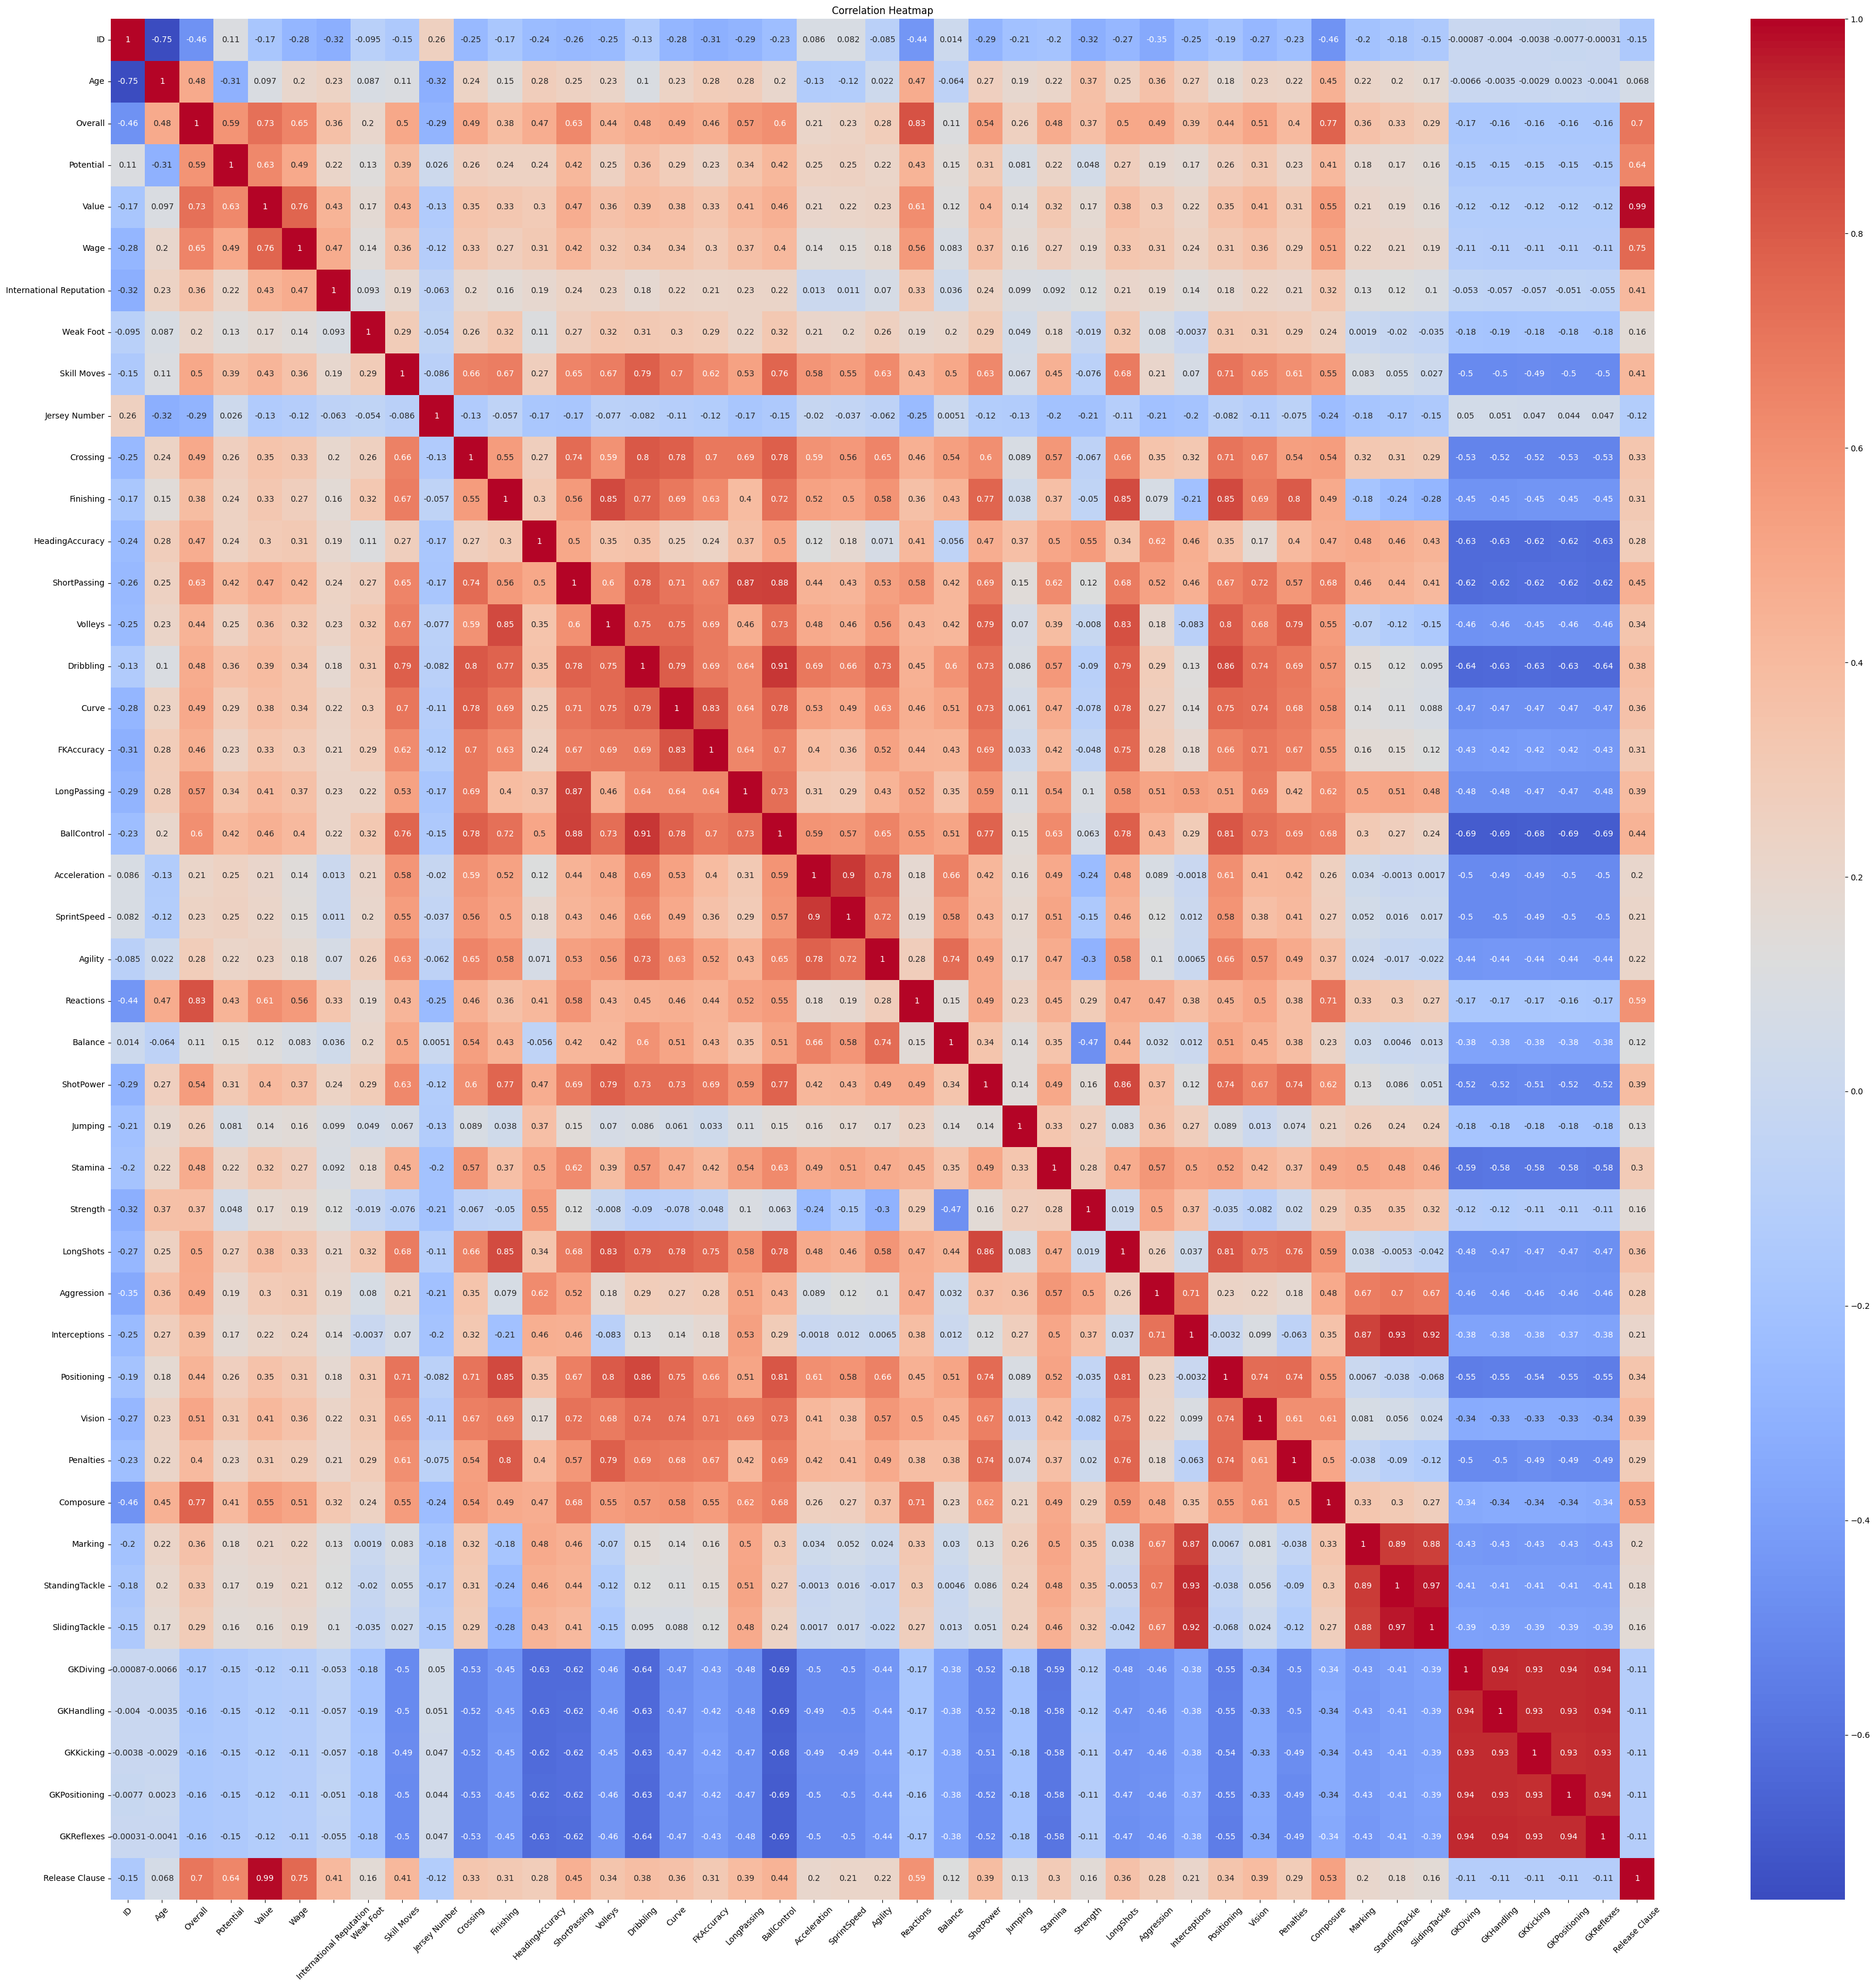

In [76]:
#correlation
corr_matrix = df.corr(numeric_only=True)

# Plot heatmap
plt.figure(figsize=(35,34))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# SCALING AND ENCODING

In [42]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

preprocessor = ColumnTransformer([
    ('num', StandardScaler(), numerical_cols),
    ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), categorical_cols)
])


In [43]:
preprocessor

ColumnTransformer(transformers=[('num', StandardScaler(),
                                 ['ID', 'Age', 'Overall', 'Potential', 'Wage',
                                  'International Reputation', 'Weak Foot',
                                  'Skill Moves', 'Jersey Number', 'Crossing',
                                  'Finishing', 'HeadingAccuracy',
                                  'ShortPassing', 'Volleys', 'Dribbling',
                                  'Curve', 'FKAccuracy', 'LongPassing',
                                  'BallControl', 'Acceleration', 'SprintSpeed',
                                  'Agility', 'Reactions', 'Balance',
                                  'ShotPower', 'Jumping', 'Stamina', 'Strength',
                                  'LongShots', 'Aggression', ...]),
                                ('cat',
                                 OneHotEncoder(drop='first',
                                               handle_unknown='ignore'),
                                 ['Name', 'Nationality', 'Club',
                                  'Preferred Foot', 'Work Rate', 'Body Type',
                                  'Position', 'Joined', 'Contract Valid Until',
                                  'Height', 'Weight'])])

# MODEL

In [44]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression

model = Pipeline([
    ('preprocessing', preprocessor),
    ('regression', LinearRegression())
])


In [45]:
model

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['ID', 'Age', 'Overall',
                                                   'Potential', 'Wage',
                                                   'International Reputation',
                                                   'Weak Foot', 'Skill Moves',
                                                   'Jersey Number', 'Crossing',
                                                   'Finishing',
                                                   'HeadingAccuracy',
                                                   'ShortPassing', 'Volleys',
                                                   'Dribbling', 'Curve',
                                                   'FKAccuracy', 'LongPassing',
                                                   'BallControl',
                                                   'Acceleration',
                                                   'SprintSpeed', 'Agility',
                                                   'Reactions', 'Balance',
                                                   'ShotPower', 'Jumping',
                                                   'Stamina', 'Strength',
                                                   'LongShots', 'Aggression', ...]),
                                                 ('cat',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore'),
                                                  ['Name', 'Nationality',
                                                   'Club', 'Preferred Foot',
                                                   'Work Rate', 'Body Type',
                                                   'Position', 'Joined',
                                                   'Contract Valid Until',
                                                   'Height', 'Weight'])])),
                ('regression', LinearRegression())])

# TRAIN TEST SPLIT

In [46]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


# PREDICTION

In [69]:
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

c:\Users\panka\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [0, 1, 7, 10] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


# ACCURACY

In [70]:
from sklearn.metrics import mean_squared_error, r2_score

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Mean Squared Error:", mse)
print(f"R^2 Score:", r2*100)


Mean Squared Error: 137345796487.10884
R^2 Score: 98.16623421158748


# SCATTERPLOT FOR ACTUAL VS PREDICTED  

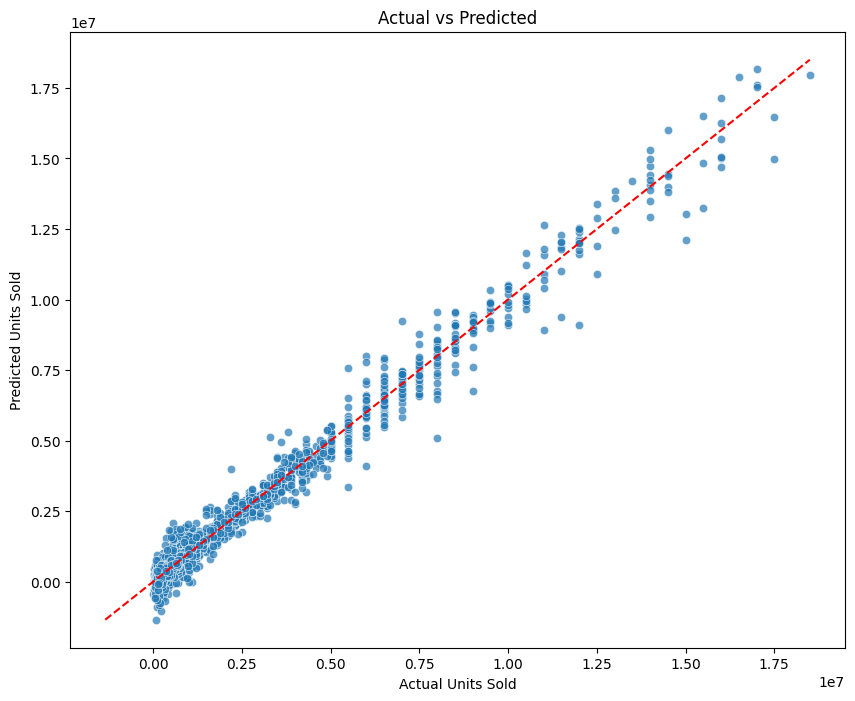

In [71]:
results_df = pd.DataFrame()
results_df['Actual'] = y_test.values
results_df['Predicted'] = y_pred

plt.figure(figsize=(10, 8))
sns.scatterplot(data=results_df, x='Actual', y='Predicted', alpha=0.7)
plt.title('Actual vs Predicted')
plt.xlabel('Actual Units Sold')
plt.ylabel('Predicted Units Sold')
plt.plot([results_df.min().min(), results_df.max().max()], 
         [results_df.min().min(), results_df.max().max()], 
         color='red', linestyle='--')  # identity line
plt.show()

# HISTPLOT FOR RESIDUALS

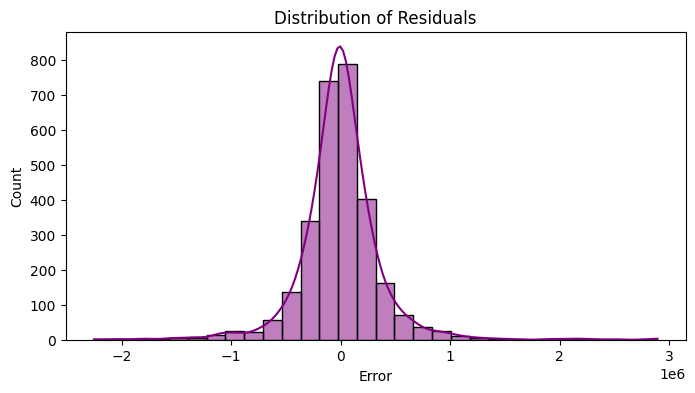

In [72]:
residuals = y_test - y_pred

plt.figure(figsize=(8, 4))
sns.histplot(residuals, bins=30, kde=True, color='purple')
plt.title('Distribution of Residuals')
plt.xlabel('Error')
plt.show()
